Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import seaborn as sns
import sys

sys.path.insert(0,"..")

# Import your implementations
from students import data_processing, regression, classification, evaluation

Load and Preprocess Data

In [2]:
# Load data
df = data_processing.load_heart_disease_data('../data/heart_disease_uci.csv')
print(f"Loaded data shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum().sum()} total missing")

# Preprocess
df_clean = data_processing.preprocess_data(df)
print(f"\nPreprocessed data shape: {df_clean.shape}")
print(f"Data types: {df_clean.dtypes.unique()}")

Loaded data shape: (920, 15)
Columns: ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Missing values:
1759 total missing

Preprocessed data shape: (920, 23)
Data types: [dtype('int64') dtype('float64')]


Linear Regression with ElasticNet

Regression data shapes: X=(890, 22), y=(890,)
Train shape: (712, 22), Test shape: (178, 22)

Training ElasticNet grid search...
Index(['l1_ratio', 'alpha', 'r2_score', 'model'], dtype='str')
Grid search results shape: (9, 4)
R² range: 0.486 to 0.570


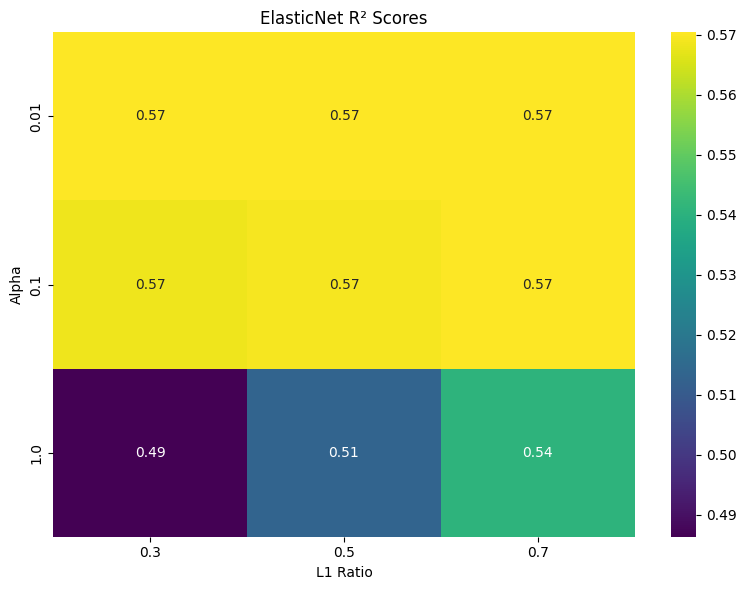


Best ElasticNet:
  l1_ratio: 0.5
  alpha: 0.1
  Test R²: 0.568
{'train_r2': np.float64(0.5703797295297218), 'model': ElasticNet(alpha=0.1, max_iter=5000, random_state=42), 'best_l1_ratio': 0.5, 'best_alpha': 0.1, 'test_r2': np.float64(0.5681378442101096), 'results_df':    mean_fit_time  std_fit_time  mean_score_time  std_score_time  param_alpha  \
0       0.002138      0.000248         0.000689        0.000090         0.01   
1       0.002724      0.000123         0.000820        0.000142         0.01   
2       0.003428      0.000227         0.000797        0.000042         0.01   
3       0.001405      0.000033         0.000621        0.000078         0.10   
4       0.001441      0.000261         0.000606        0.000091         0.10   
5       0.001226      0.000101         0.000474        0.000008         0.10   
6       0.001342      0.000191         0.000590        0.000100         1.00   
7       0.001353      0.000259         0.000545        0.000081         1.00   
8       0

In [3]:
# Prepare regression data
X_reg, y_reg = data_processing.prepare_regression_data(df_clean, target='chol')
print(f"Regression data shapes: X={X_reg.shape}, y={y_reg.shape}")

# Split and scale
X_train_reg, X_test_reg, y_train_reg, y_test_reg, scaler_reg = data_processing.split_and_scale(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Train shape: {X_train_reg.shape}, Test shape: {X_test_reg.shape}")


# Train ElasticNet with grid search
print("\nTraining ElasticNet grid search...")
results = regression.train_elasticnet_grid(
    X_train_reg, y_train_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)

print(results.columns)
print(f"Grid search results shape: {results.shape}")
print(f"R² range: {results['r2_score'].min():.3f} to {results['r2_score'].max():.3f}")


# Create heatmap
fig = regression.create_r2_heatmap(
    results,
    [0.3, 0.5, 0.7],
    [0.01, 0.1, 1.0]
)
plt.title('ElasticNet R² Scores')
plt.tight_layout()
plt.show()



# Get best model
reg_best = regression.get_best_elasticnet_model(
    X_train_reg, y_train_reg, X_test_reg, y_test_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)
print(f"\nBest ElasticNet:")
print(f"  l1_ratio: {reg_best['best_l1_ratio']}")
print(f"  alpha: {reg_best['best_alpha']}")
print(f"  Test R²: {reg_best['test_r2']:.3f}")

print(reg_best)

Classification with Logistic Regression and k-NN

In [4]:
# Prepare classification data
X_clf, y_clf = data_processing.prepare_classification_data(df_clean, target='num')
print(f"Classification data shapes: X={X_clf.shape}, y={y_clf.shape}")
print(f"Class distribution: {np.bincount(y_clf.astype(int))}")

# Split and scale
X_train_clf, X_test_clf, y_train_clf, y_test_clf, scaler_clf = data_processing.split_and_scale(
    X_clf, y_clf, test_size=0.2, random_state=42
)
print(f"\nTrain shape: {X_train_clf.shape}, Test shape: {X_test_clf.shape}")

Classification data shapes: X=(920, 21), y=(920,)
Class distribution: [411 509]

Train shape: (736, 21), Test shape: (184, 21)


Logistic Regression

Training Logistic Regression grid search...
Best parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

Logistic Regression Test AUC: 0.910


c:\Users\weiri\OneDrive\Attachments\Documents\assignment-2-supervised-learning-lauren-weir\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\weiri\OneDrive\Attachments\Documents\assignment-2-supervised-learning-lauren-weir\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


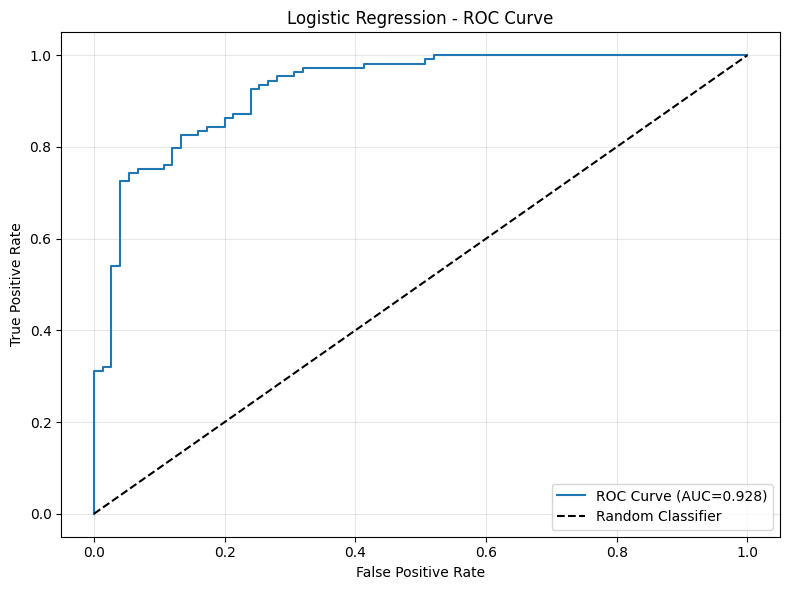

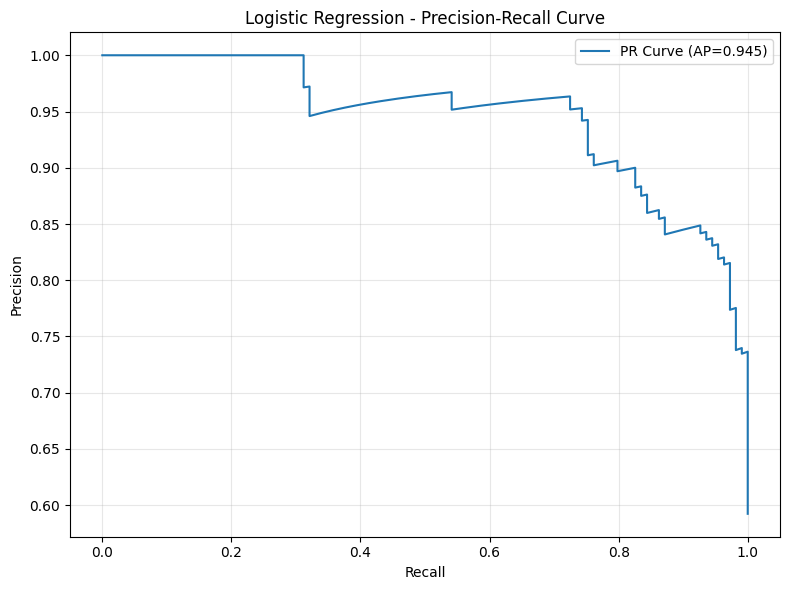

In [5]:
# Train logistic regression
print("Training Logistic Regression grid search...")
gs_lr = classification.train_logistic_regression_grid(X_train_clf, y_train_clf)
print(f"Best parameters: {gs_lr.best_params_}")

# Get best model
lr_best = classification.get_best_logistic_regression(
    X_train_clf, y_train_clf, X_test_clf, y_test_clf
)

print(f"\nLogistic Regression Test AUC: {lr_best['test_auc']:.3f}")

# Get probability predictions for curves
y_pred_lr = lr_best['model'].predict_proba(X_test_clf)[:, 1]

# Plot AUROC curve
fig_lr = evaluation.generate_auroc_curve(y_test_clf, y_pred_lr, model_name='Logistic Regression')
plt.title('Logistic Regression - ROC Curve')
plt.tight_layout()
plt.show()

# Plot AUPRC curve
fig_lr2 = evaluation.generate_auprc_curve(y_test_clf, y_pred_lr, model_name='Logistic Regression')
plt.tight_layout()
plt.title('Logistic Regression - Precision-Recall Curve')
plt.show()

k-NN Classification

Training k-NN grid search...
Best parameters: {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'uniform'}

k-NN Test AUC: 0.915


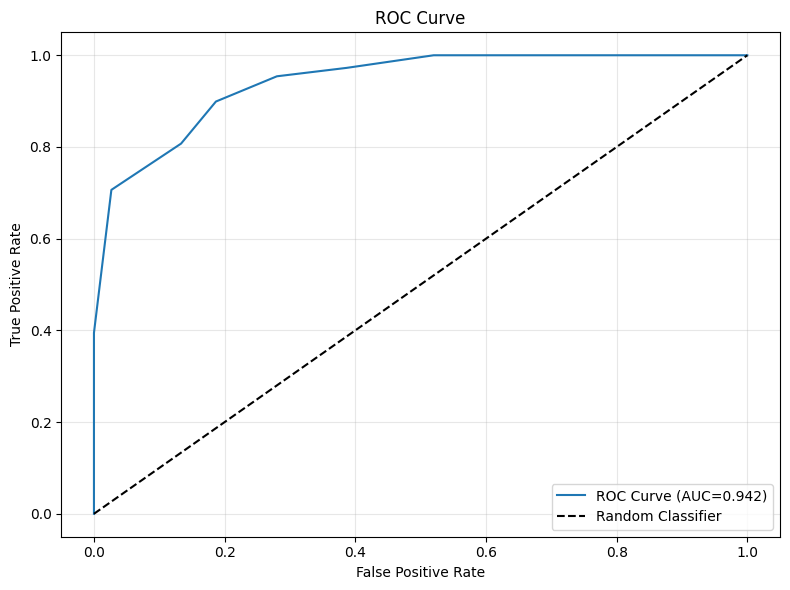

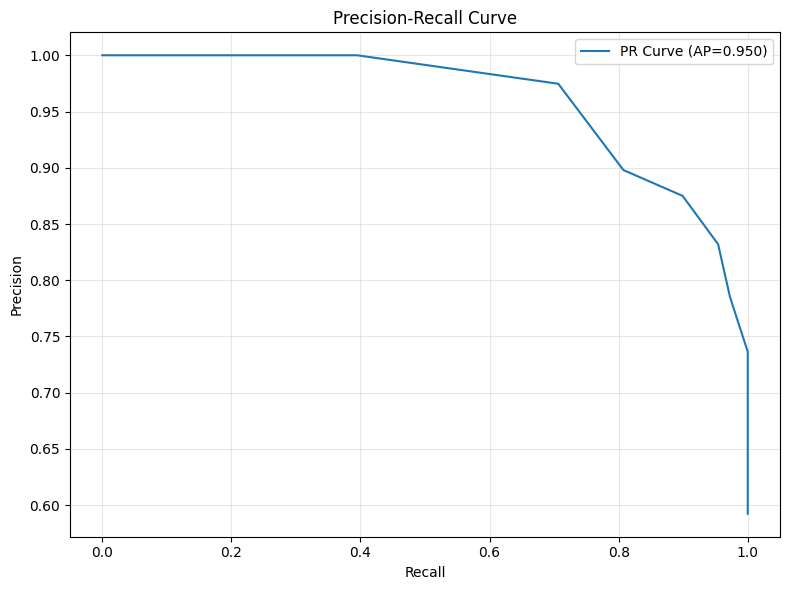

In [ ]:
# Train k-NN
print("Training k-NN grid search...")
gs_knn = classification.train_knn_grid(X_train_clf, y_train_clf)
print(f"Best parameters: {gs_knn.best_params_}")

# Get best model
knn_best = classification.get_best_knn(
    X_train_clf, y_train_clf, X_test_clf, y_test_clf
)

print(f"\nk-NN Test AUC: {knn_best['test_auc']:.3f}")

# Get probability predictions
y_pred_knn = knn_best['model'].predict_proba(X_test_clf)[:, 1]

# Plot AUROC curve
fig_knn = evaluation.generate_auroc_curve(y_test_clf, y_pred_knn, model_name ='k-NN')
plt.title('kNN - ROC Curve')
plt.tight_layout()
plt.show()

# Plot AUPRC curve
fig_knn2 = evaluation.generate_auprc_curve(y_test_clf, y_pred_knn, model_name ='k-NN')
plt.title('kNN - Precision-Recall Curve')
plt.tight_layout()
plt.show()


Model Comparison

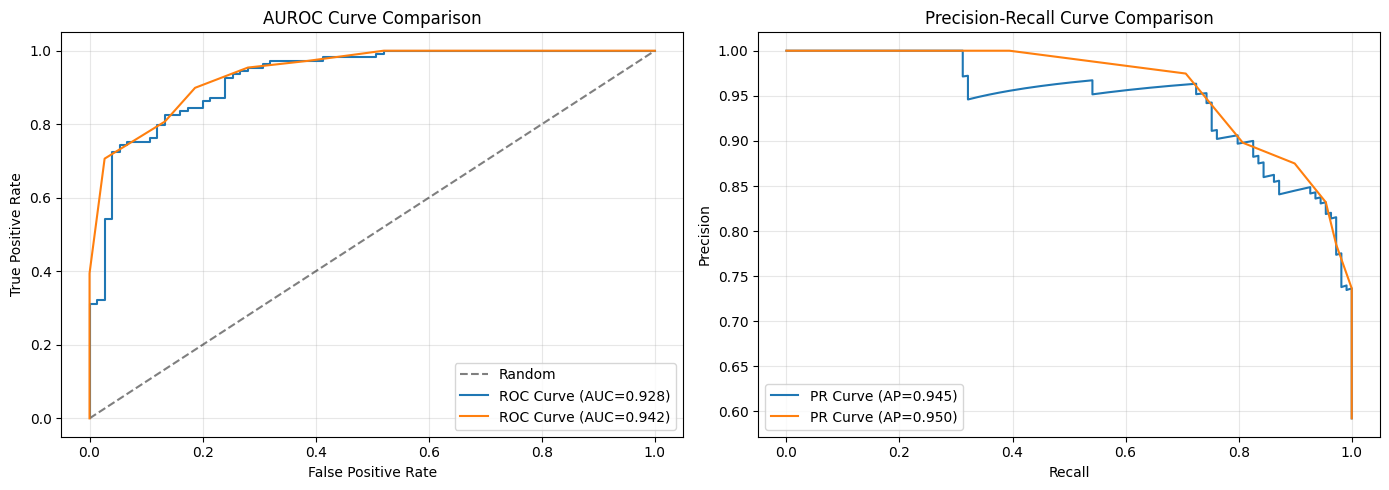


MODEL COMPARISON SUMMARY
Logistic Regression:
  AUROC: 0.928
  AUPRC: 0.945

k-NN:
  AUROC: 0.942
  AUPRC: 0.950

Better model: k-NN


In [8]:
# Compare AUROC curves

auc_lr = evaluation.calculate_auroc_score(y_test_clf, y_pred_lr)
ap_lr = evaluation.calculate_auprc_score(y_test_clf, y_pred_lr)
auc_knn = evaluation.calculate_auroc_score(y_test_clf, y_pred_knn)
ap_knn = evaluation.calculate_auprc_score(y_test_clf, y_pred_knn)

evaluation.plot_comparison_curves(y_test_clf, y_pred_lr, y_pred_knn,
                          output_path=None)


plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"Logistic Regression:")
print(f"  AUROC: {auc_lr:.3f}")
print(f"  AUPRC: {ap_lr:.3f}")
print(f"\nk-NN:")
print(f"  AUROC: {auc_knn:.3f}")
print(f"  AUPRC: {ap_knn:.3f}")
print(f"\nBetter model: {'Logistic Regression' if auc_lr > auc_knn else 'k-NN'}")
print("="*60)